# Notebook 04: Land Value Decomposition

**Goal**: Use the trained AVM to decompose each property's total market
value into a **site (land) component** and an **improvement component**.

**Approach**: Two methods compared:
1. **Hedonic subtraction**: Train a "land-only" model using only land-related
   features → predicted value ≈ site value. Improvement value = total - site.
2. **CCAO assessed value split**: Use the Assessor's existing land/bldg
   assessed values as a benchmark.

The decomposition feeds directly into the tax shift simulation (Notebook 05).

In [13]:
import pandas as pd
import numpy as np
import json
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

In [14]:
# Load data and models
df_train = pd.read_parquet("../data/processed/train_split.parquet")
df_val = pd.read_parquet("../data/processed/val_split.parquet")
df_test = pd.read_parquet("../data/processed/test_split.parquet")
assessment = pd.read_parquet("../data/processed/assessment_clean.parquet")
land_rates = pd.read_parquet("../data/raw/land_nbhd_rate_data.parquet")

with open("../data/processed/feature_config.json") as f:
    config = json.load(f)

TARGET = config["target_col"]
CLASS_COL = config["class_col"]
lgb_full_model = lgb.Booster(model_file="../outputs/models/lgb_avm_model.txt")

print(f"Assessment data: {assessment.shape}")
print(f"Land rates: {land_rates.shape}")

Assessment data: (1100150, 199)
Land rates: (5040, 3)


## Method 1: Hedonic Land-Only Model

Train a model using **only features that describe the land/location** — 
NOT the improvement. The prediction = site value estimate.
The residual (total predicted - site predicted) = improvement value.

In [15]:
# === Define land-only features ===
# These describe WHERE the property is and WHAT the land is like,
# but NOT what's built on it.

LAND_FEATURES = [
    # Land physical characteristics
    "char_land_sf",
    
    # Location
    "loc_latitude", "loc_longitude",
    "loc_access_cmap_walk_total_score",
    "loc_access_cmap_walk_nta_score",
    "loc_env_flood_fs_factor",
    "loc_census_tract_geoid",
    "loc_school_elementary_district_geoid",
    "loc_school_secondary_district_geoid",
    "loc_tax_municipality_name",
    
    # Proximity (all location-driven, not improvement-driven)
    "prox_lake_michigan_dist_ft",
    "prox_nearest_cta_stop_dist_ft",
    "prox_nearest_metra_stop_dist_ft",
    "prox_nearest_park_dist_ft",
    "prox_nearest_hospital_dist_ft",
    "prox_nearest_water_dist_ft",
    "prox_nearest_golf_course_dist_ft",
    "prox_nearest_railroad_dist_ft",
    "prox_nearest_road_highway_dist_ft",
    "prox_nearest_vacant_land_dist_ft",
    "prox_nearest_university_dist_ft",
    "prox_nearest_bike_trail_dist_ft",
    "prox_nearest_cemetery_dist_ft",
    "prox_airport_dnl_total",
    "prox_num_pin_in_half_mile",
    "prox_avg_school_rating_in_half_mile",
    "prox_num_bus_stop_in_half_mile",
    "prox_nearest_stadium_dist_ft",
    
    # ACS/Census (neighborhood-level, location-driven)
    "acs5_median_income_household_past_year",
    "acs5_median_income_per_capita_past_year",
    "acs5_median_household_renter_occupied_gross_rent",
    "acs5_percent_household_owner_occupied",
    "acs5_percent_income_below_poverty_level",
    "acs5_percent_employment_unemployed",
    "acs5_percent_education_bachelor",
    "acs5_percent_education_graduate",
    "acs5_median_age_total",
    
    # Parcel shape (land geometry, not building)
    "shp_parcel_centroid_dist_ft_sd",
    "shp_parcel_edge_len_ft_sd",
    "shp_parcel_interior_angle_sd",
    "shp_parcel_mrr_area_ratio",
    "shp_parcel_mrr_side_ratio",
    "shp_parcel_num_vertices",
    
    # Neighborhood/township identifiers
    "meta_nbhd_code",
    "meta_township_code",
    
    # Engineered land features
    "feat_log_land_sf",
    "feat_large_lot",
    
    # Tax rate (location-determined)
    "other_tax_bill_rate",
]

# Also include time features for the training phase
TIME_FEATS = [c for c in config["time_features"] if c in df_train.columns]

# Filter to existing columns
LAND_FEATURES = [c for c in LAND_FEATURES if c in df_train.columns]
LAND_FEATURES_WITH_TIME = LAND_FEATURES + TIME_FEATS

LAND_NUMERIC = [c for c in LAND_FEATURES_WITH_TIME 
                if df_train[c].dtype in ["float64","float32","int64","int32","bool"]]
LAND_CATEGORICAL = [c for c in LAND_FEATURES_WITH_TIME 
                    if c not in LAND_NUMERIC and c in df_train.columns]

print(f"Land-only features: {len(LAND_FEATURES)} ({len(LAND_NUMERIC)} num, {len(LAND_CATEGORICAL)} cat)")
print(f"  (+ {len(TIME_FEATS)} time features for training)")

Land-only features: 48 (49 num, 7 cat)
  (+ 8 time features for training)


In [16]:
# Prepare data for land-only model
for col in LAND_CATEGORICAL:
    for df in [df_train, df_val, df_test, assessment]:
        if col in df.columns:
            df[col] = pd.Categorical(df[col], categories=df_train[col].astype("category").cat.categories)

X_train_land = df_train[LAND_FEATURES_WITH_TIME]
X_val_land = df_val[LAND_FEATURES_WITH_TIME]
X_test_land = df_test[LAND_FEATURES_WITH_TIME]

y_train = df_train[TARGET]
y_val = df_val[TARGET]
y_test = df_test[TARGET]

/var/folders/ks/kb5pst5x5t9_1l4qvp48_dnw0000gn/T/ipykernel_3152/3031144078.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[col] = pd.Categorical(df[col], categories=df_train[col].astype("category").cat.categories)
/var/folders/ks/kb5pst5x5t9_1l4qvp48_dnw0000gn/T/ipykernel_3152/3031144078.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[col] = pd.Categorical(df[col], categories=df_train[col].astype("category").cat.categories)
/var/folders/ks/kb5pst5x5t9_1l4qvp48_dnw0000gn/T/ipykernel_3152/3031144078.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[col] = pd.Categorical(df[col], c

In [17]:
# Train land-only LightGBM model
lgb_train_land = lgb.Dataset(
    X_train_land, label=y_train,
    categorical_feature=LAND_CATEGORICAL, free_raw_data=False,
)
lgb_val_land = lgb.Dataset(
    X_val_land, label=y_val,
    categorical_feature=LAND_CATEGORICAL, reference=lgb_train_land, free_raw_data=False,
)

land_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 256,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.5,
    "lambda_l2": 2.0,
    "cat_smooth": 50,
    "verbose": -1,
    "n_jobs": -1,
    "seed": 42,
}

print("Training land-only model...")
land_model = lgb.train(
    land_params,
    lgb_train_land,
    num_boost_round=2000,
    valid_sets=[lgb_train_land, lgb_val_land],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ],
)
print(f"Best iteration: {land_model.best_iteration}")

Training land-only model...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 119508	valid's rmse: 150880
[200]	train's rmse: 111553	valid's rmse: 149680
[300]	train's rmse: 105879	valid's rmse: 149356
Early stopping, best iteration is:
[266]	train's rmse: 107686	valid's rmse: 149329
Best iteration: 266


In [18]:
# Evaluate land-only model on test set
land_pred_test = land_model.predict(X_test_land)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(y_test, land_pred_test))
r2 = r2_score(y_test, land_pred_test)
mape = mean_absolute_percentage_error(y_test, land_pred_test)

print(f"\n=== Land-Only Model Performance (Test Set) ===")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R²:   {r2:.4f}")
print(f"  MAPE: {mape:.2%}")
print(f"\nNote: This model SHOULD perform worse than the full AVM.")
print(f"The gap represents the value information contained in improvements.")


=== Land-Only Model Performance (Test Set) ===
  RMSE: $161,018
  R²:   0.6961
  MAPE: 34.71%

Note: This model SHOULD perform worse than the full AVM.
The gap represents the value information contained in improvements.


## Predict Site Values for ALL Assessment Properties

In [19]:
# For the assessment data, we need to handle time features
# CCAO sets all assessment dates to Jan 1 of assessment year
assess_land = assessment[LAND_FEATURES].copy()

# Add time features — set to a reference date
# You'll need to check which time columns the model expects
for col in TIME_FEATS:
    if col not in assess_land.columns:
        # Set reasonable defaults for the assessment date
        if "year" in col:
            assess_land[col] = 2025
        elif "day_of_year" in col:
            assess_land[col] = 1
        elif "day_of_week" in col:
            assess_land[col] = 3  # Wednesday
        elif "day_of_month" in col:
            assess_land[col] = 1
        elif "quarter" in col:
            assess_land[col] = "Q1"
        elif "month" in col:
            assess_land[col] = "Jan"
        elif "sale_day" in col:
            # Days since Jan 1, 1997 to Jan 1, 2025 = ~10227
            assess_land[col] = 10227
        elif "post_covid" in col:
            assess_land[col] = True
        else:
            assess_land[col] = 0

# Ensure categoricals match
for col in LAND_CATEGORICAL:
    if col in assess_land.columns:
        assess_land[col] = pd.Categorical(assess_land[col], categories=df_train[col].astype("category").cat.categories)

# Predict site values
print("Predicting site values for all assessment properties...")
assessment["pred_site_value"] = land_model.predict(assess_land[LAND_FEATURES_WITH_TIME])

/var/folders/ks/kb5pst5x5t9_1l4qvp48_dnw0000gn/T/ipykernel_3152/2669754911.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  assess_land[col] = pd.Categorical(assess_land[col], categories=df_train[col].astype("category").cat.categories)


Predicting site values for all assessment properties...


In [20]:
# Also predict total market value using the full AVM
# Get the exact feature names the model expects
FULL_FEATURES = lgb_full_model.feature_name()

# The model stores which features were categorical during training.
# We must provide the SAME number of categoricals in the same order.
# Detect which columns the model treated as categorical from its
# pandas_categorical attribute (list of category lists, one per cat column).
n_model_cats = len(lgb_full_model.pandas_categorical)

# Identify categorical columns: any feature that is NOT numeric in df_train
cat_features_at_train_time = [
    c for c in FULL_FEATURES
    if c in df_train.columns and not pd.api.types.is_numeric_dtype(df_train[c])
]
print(f"Model expects {n_model_cats} categorical features")
print(f"Detected {len(cat_features_at_train_time)} categoricals from training data dtypes")

# Build assessment prediction dataframe with exactly the model's features
assess_full = assessment[FULL_FEATURES].copy()

# Set categoricals to match training data categories exactly
for i, col in enumerate(cat_features_at_train_time):
    train_cats = lgb_full_model.pandas_categorical[i]
    assess_full[col] = pd.Categorical(assess_full[col], categories=train_cats)

print("Predicting total market values using full AVM...")
assessment["pred_total_value"] = lgb_full_model.predict(assess_full)

Model expects 23 categorical features
Detected 23 categoricals from training data dtypes
Predicting total market values using full AVM...


In [21]:
# === Compute improvement value by subtraction ===
assessment["pred_improvement_value"] = (
    assessment["pred_total_value"] - assessment["pred_site_value"]
)

# Floor improvement value at 0 (can't be negative)
assessment["pred_improvement_value"] = assessment["pred_improvement_value"].clip(lower=0)

# Recalculate site value to ensure total = site + improvement
# (adjusting site down if improvement was floored)
assessment["pred_site_value_adj"] = (
    assessment["pred_total_value"] - assessment["pred_improvement_value"]
)

# Site-to-total ratio
assessment["site_value_ratio"] = (
    assessment["pred_site_value_adj"] / 
    assessment["pred_total_value"].replace(0, np.nan)
)

print("=== Land Value Decomposition Summary ===")
print(f"Total properties: {len(assessment):,}")
print(f"\nPredicted Total Value:")
print(assessment["pred_total_value"].describe())
print(f"\nPredicted Site Value:")
print(assessment["pred_site_value_adj"].describe())
print(f"\nPredicted Improvement Value:")
print(assessment["pred_improvement_value"].describe())
print(f"\nSite-to-Total Ratio:")
print(assessment["site_value_ratio"].describe())

=== Land Value Decomposition Summary ===
Total properties: 1,100,150

Predicted Total Value:
count    1.100150e+06
mean     3.883205e+05
std      2.605557e+05
min      2.452959e+04
25%      2.284064e+05
50%      3.168056e+05
75%      4.554476e+05
max      1.890745e+06
Name: pred_total_value, dtype: float64

Predicted Site Value:
count    1.100150e+06
mean     3.538492e+05
std      2.206084e+05
min      2.452959e+04
25%      2.175767e+05
50%      2.983040e+05
75%      4.161836e+05
max      1.672362e+06
Name: pred_site_value_adj, dtype: float64

Predicted Improvement Value:
count    1.100150e+06
mean     3.447126e+04
std      7.925993e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.108504e+04
max      1.061105e+06
Name: pred_improvement_value, dtype: float64

Site-to-Total Ratio:
count    1.100150e+06
mean     9.353507e-01
std      1.071024e-01
min      2.435559e-01
25%      9.033375e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Na

## Method 2: CCAO Assessed Value Split (Benchmark)

In [22]:
# The CCAO's assessed values already contain a land/building split.
# Check if this data is embedded in the assessment dataset or if we
# need to pull it from the Open Data Portal.

# Look for land/bldg assessed value columns
av_cols = [c for c in assessment.columns if "land" in c.lower() or "bldg" in c.lower() 
           or "av_" in c.lower() or "assessed" in c.lower()]
print(f"Assessed value columns found: {av_cols}")

# If not in the model data, we'll note that you need to download from Open Data Portal
if not av_cols:
    print("""
    NOTE: The model input data may not contain the Assessor's land/bldg split.
    You can download it from the Cook County Open Data Portal:
    
    Dataset: Assessor - Historic Assessed Values
    URL: https://datacatalog.cookcountyil.gov/Property-Taxation/Assessor-Historic-Assessed-Values/uzyt-m557
    
    Columns: pin, year, class, land (assessed), bldg (assessed), tot (assessed), stage
    
    Download as CSV, then:
        hist_av = pd.read_csv("../data/raw/historic_assessed_values.csv")
        hist_av = hist_av[hist_av["year"] == 2024]  # or most recent year
        hist_av = hist_av[hist_av["stage"] == "board certified"]  # final values
        
    Then merge on PIN:
        assessment = assessment.merge(hist_av[["pin","land","bldg","tot"]], 
                                       left_on="meta_pin", right_on="pin", how="left")
    """)

Assessed value columns found: ['ind_pin_is_multiland', 'meta_pin_num_landlines', 'meta_mailed_bldg', 'meta_mailed_land', 'meta_certified_bldg', 'meta_certified_land', 'meta_board_bldg', 'meta_board_land', 'meta_1yr_pri_board_bldg', 'meta_1yr_pri_board_land', 'meta_2yr_pri_board_bldg', 'meta_2yr_pri_board_land', 'char_bldg_sf', 'char_land_sf', 'char_land_sf_95_percentile', 'ind_land_gte_95_percentile', 'char_bldg_sf_95_percentile', 'ind_bldg_gte_95_percentile', 'ind_land_bldg_ratio_gte_10', 'prox_nearest_vacant_land_dist_ft', 'feat_bldg_to_land_ratio', 'feat_log_land_sf', 'feat_log_bldg_sf']


## Visualization of Decomposition Results

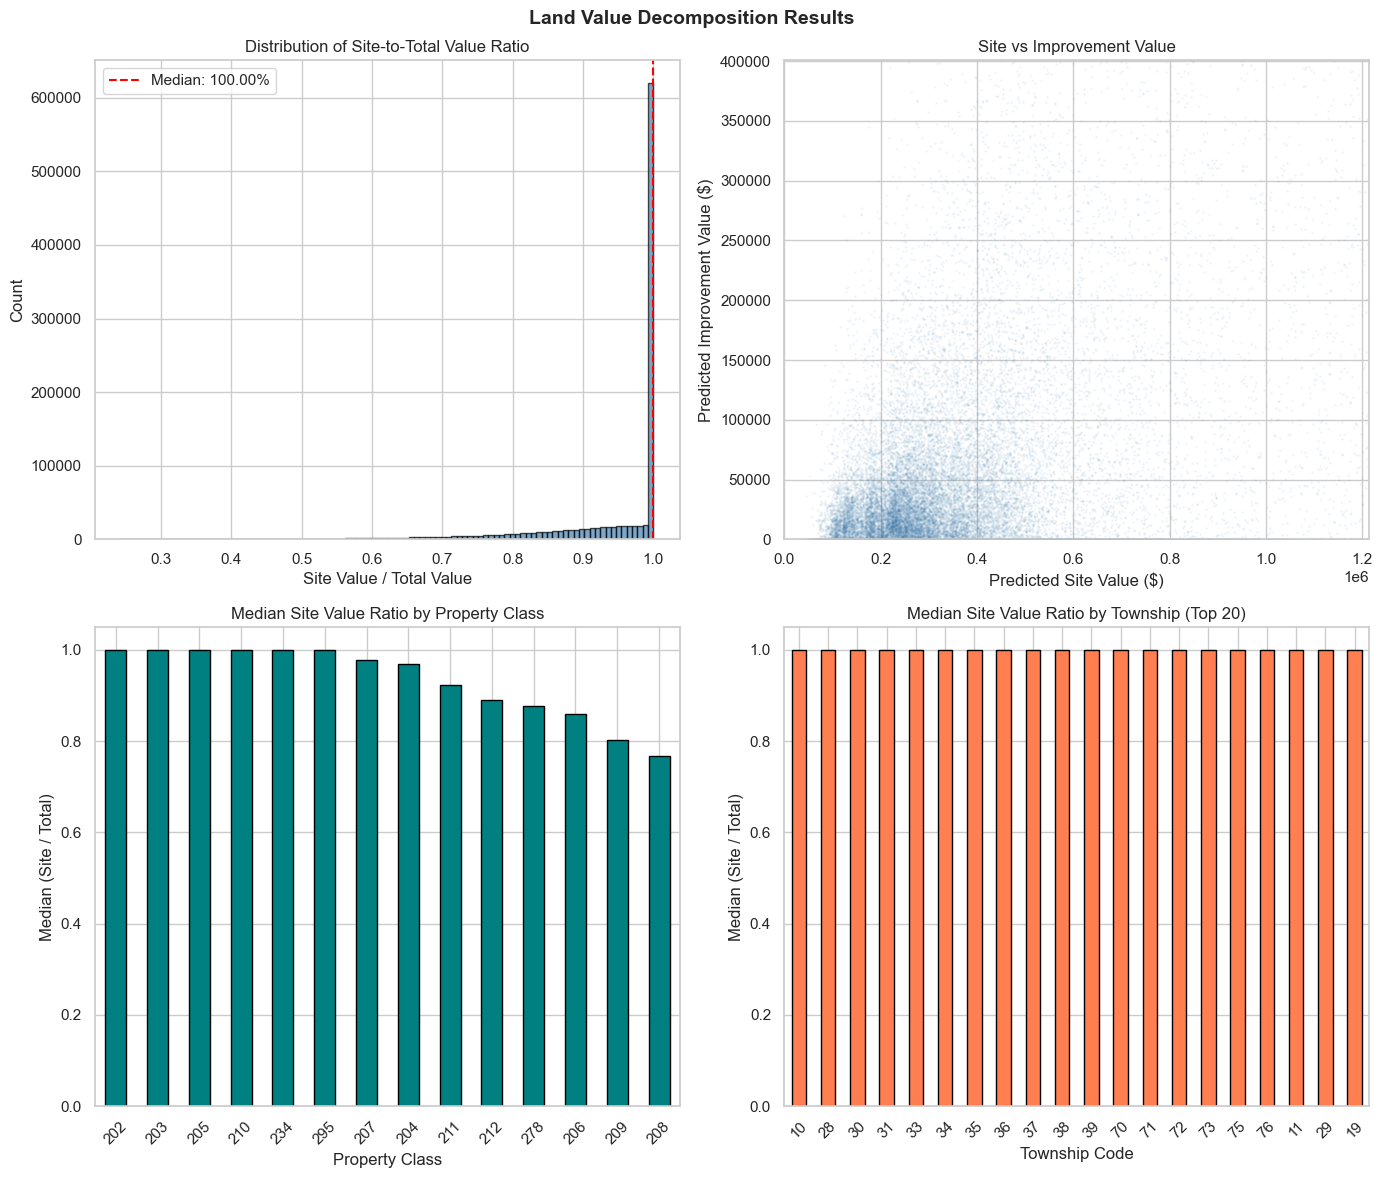

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Distribution of site value ratio
ax = axes[0, 0]
valid_ratio = assessment["site_value_ratio"].dropna()
valid_ratio = valid_ratio[(valid_ratio >= 0) & (valid_ratio <= 1)]
ax.hist(valid_ratio, bins=100, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(valid_ratio.median(), color="red", linestyle="--",
           label=f"Median: {valid_ratio.median():.2%}")
ax.set_title("Distribution of Site-to-Total Value Ratio")
ax.set_xlabel("Site Value / Total Value")
ax.set_ylabel("Count")
ax.legend()

# 2. Site vs Improvement value scatter
ax = axes[0, 1]
sample = assessment.sample(min(50000, len(assessment)), random_state=42)
ax.scatter(sample["pred_site_value_adj"], sample["pred_improvement_value"],
           alpha=0.05, s=1, color="steelblue")
ax.set_xlabel("Predicted Site Value ($)")
ax.set_ylabel("Predicted Improvement Value ($)")
ax.set_title("Site vs Improvement Value")
ax.set_xlim(0, sample["pred_site_value_adj"].quantile(0.99))
ax.set_ylim(0, sample["pred_improvement_value"].quantile(0.99))

# 3. Site value ratio by property class
ax = axes[1, 0]
class_ratios = (
    assessment.groupby(CLASS_COL)["site_value_ratio"]
    .median()
    .sort_values(ascending=False)
)
class_ratios.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
ax.set_title("Median Site Value Ratio by Property Class")
ax.set_ylabel("Median (Site / Total)")
ax.set_xlabel("Property Class")
ax.tick_params(axis="x", rotation=45)

# 4. Site value ratio by township
ax = axes[1, 1]
if "meta_township_code" in assessment.columns:
    twp_ratios = (
        assessment.groupby("meta_township_code")["site_value_ratio"]
        .median()
        .sort_values(ascending=False)
    )
    twp_ratios.head(20).plot(kind="bar", ax=ax, color="coral", edgecolor="black")
    ax.set_title("Median Site Value Ratio by Township (Top 20)")
    ax.set_ylabel("Median (Site / Total)")
    ax.set_xlabel("Township Code")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Land Value Decomposition Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/04_land_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## Land-Only Feature Importance

=== Land-Only Model: Top 20 Features by Gain ===

                                feature         gain
    loc_school_secondary_district_geoid 5.277247e+16
   loc_school_elementary_district_geoid 3.178345e+16
                         meta_nbhd_code 2.473748e+16
                           char_land_sf 5.180795e+15
                 loc_census_tract_geoid 4.646702e+15
acs5_median_income_per_capita_past_year 4.160240e+15
                          time_sale_day 3.098969e+15
                     meta_township_code 2.607997e+15
                       feat_log_land_sf 1.825069e+15
                           loc_latitude 1.815271e+15
 acs5_median_income_household_past_year 1.290791e+15
                          loc_longitude 1.223641e+15
       prox_nearest_golf_course_dist_ft 1.098995e+15
              loc_tax_municipality_name 9.974869e+14
              shp_parcel_edge_len_ft_sd 8.808157e+14
        prox_nearest_university_dist_ft 8.506311e+14
              shp_parcel_mrr_side_ratio 8.146786e

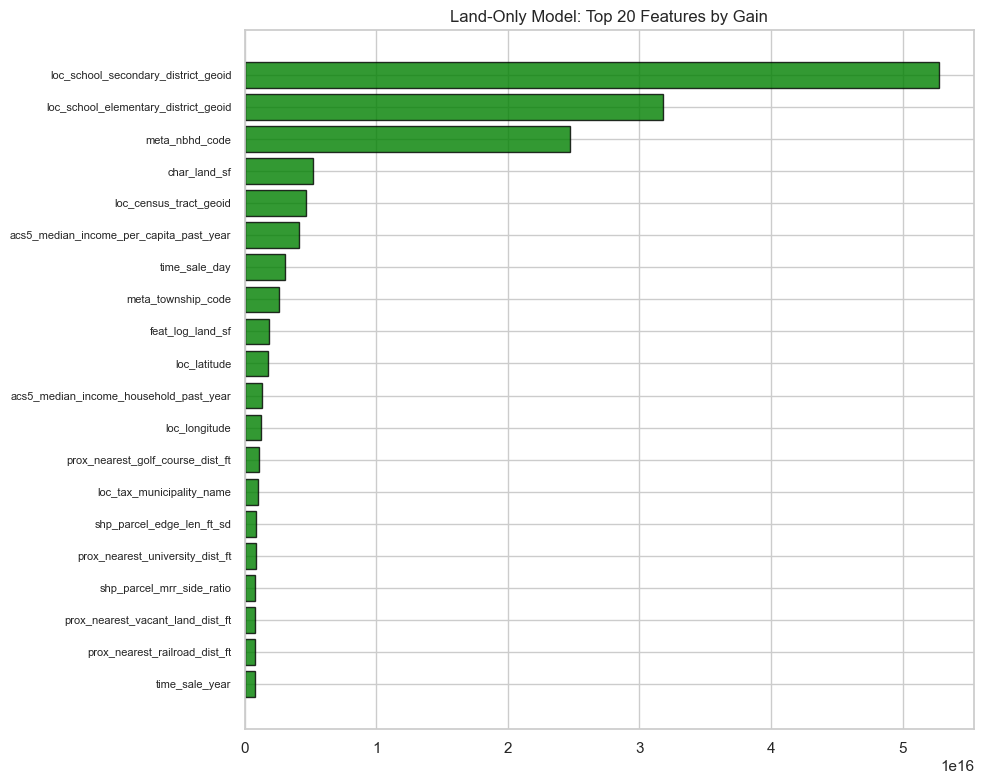

In [24]:
land_importance = pd.DataFrame({
    "feature": LAND_FEATURES_WITH_TIME,
    "gain": land_model.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)

print("=== Land-Only Model: Top 20 Features by Gain ===\n")
print(land_importance.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = land_importance.head(20)
ax.barh(range(20), top20["gain"].values, color="green", edgecolor="black", alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels(top20["feature"].values, fontsize=8)
ax.set_title("Land-Only Model: Top 20 Features by Gain")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/04_land_model_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Decomposition Results

In [25]:
# Save the assessment data with decomposition columns
output_cols = [
    "meta_pin", CLASS_COL, "meta_township_code", "meta_nbhd_code",
    "char_land_sf", "char_bldg_sf",
    "pred_total_value", "pred_site_value_adj", "pred_improvement_value",
    "site_value_ratio",
]
output_cols = [c for c in output_cols if c in assessment.columns]

decomposed = assessment[output_cols].copy()
decomposed.to_parquet("../data/processed/assessment_decomposed.parquet", index=False)

# Save land model
land_model.save_model("../outputs/models/lgb_land_model.txt")

print(f"Saved: ../data/processed/assessment_decomposed.parquet ({len(decomposed):,} rows)")
print(f"Saved: ../outputs/models/lgb_land_model.txt")

Saved: ../data/processed/assessment_decomposed.parquet (1,100,150 rows)
Saved: ../outputs/models/lgb_land_model.txt
